## Mini Project 2: Automated Essay Scoring (AES)

### Author: Donald Yeboah


## Project Summary

In this project, I use Automated Essay Scoring (AES) techniques to predict an ordinal score (in the range 1–5) from essay text. 

### Some assumptions I adopted include:

- Since the essays come from multiple prompts/topics without an explicit prompt identifier, we can analyze topic robustness via unsupervised topic proxies (TF-IDF with clustering) and length sensitivity.
- Scores are integer and ordered; we train models that output a continuous value and then calibrate/round to valid score labels.

---

## Table of Content
- [Import Libraries](#import-libraries)
- [Data Loading](#load-data)
- [Exploratory Data Analysis](#exploratory-data-analysis-eda)
- [Text Sanity Checks](#lets-do-a-quick-text-sanity-checks)
- [Data Splitting](#lets-split-the-data-we-will-ensure-that-there-is-no-leakage-and-define-our-evaluation-criterion)
- [Handling the issue of multi-prompt data without explicit prompt IDs](#next-lets-handle-the-multi-prompt-data-without-explicit-prompt-ids-issue)
- [Feature Engineering](#feature-engineering-lets-start-with-the-classical-approach)
- [Classical Model Selection(5-fold stratified CV)](#classical-model-selection-5-fold-stratified-cv-on-train)
- [Classical Interpretability](#classical-interpretability-top-n-grams)
- [Neural Model Training](#train-neural-model)
- [Transformer Training Strategy](#transformer-training-strategy-frozen-encoder--trainable-head)
- [Transformer model](#transformer-data-pipeline-chunking--pooled-representation)
- [Validation Calibration](#validation-calibration-isotonic-regression-for-the-trasnformer-model)
- [Evaluating the Transformer](#evaluating-the-transformer-on-the-test-set)
- [Ablations & Robustness Checks](#ablations-and-robustness-checks)
- [Error Analysis](#error-analysis)
- [Major Results Summary](#major-results-summaries)



## Import Libraries

In [1]:
from __future__ import annotations

import logging
import re
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, root_mean_squared_error
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.utils.validation import check_is_fitted

import string
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from transformers import AutoModel, AutoTokenizer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import confusion_matrix



RANDOM_SEED = 13 # Are you wondering why I chose 13? Well, because there's a conspiracy that it represents bad luck, and 
# I want to prove otherwise. :)

# We can define a method to set a global seed that will ensure that this work is reproducible. 
def set_global_seed(seed: int = RANDOM_SEED) -> None:
    """Set global seeds for reproducibility across common libraries."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)


set_global_seed(RANDOM_SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)
logger = logging.getLogger("aes")

c:\Users\Others\Downloads\mini project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

Dataset format (per assignment PDF):  
- `essay_id` (string)
- `full_text` (string)
- `score` (integer)

We validate schema and basic integrity.

In [2]:
DATA_PATH = Path("Essays.csv")

def load_data(data_path = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(data_path)
    logger.info("Loaded %d rows from %s", len(df), data_path)
    return df

df = load_data()

required_cols = {"essay_id", "full_text", "score"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["essay_id"] = df["essay_id"].astype(str)
df["full_text"] = df["full_text"].astype(str)
df["score"] = pd.to_numeric(df["score"], errors="raise").astype(int)

df.head()

2026-02-26 20:05:14,241 | INFO | Loaded 17307 rows from Essays.csv


,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


## Exploratory Data Analysis (EDA)

We examine:
- Score distribution (ordinal label balance)
- Essay length distribution
- Basic text characteristics


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17307 entries, 0 to 17306
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   essay_id   17307 non-null  str  
 1   full_text  17307 non-null  str  
 2   score      17307 non-null  int64
dtypes: int64(1), str(2)
memory usage: 405.8 KB


,count
score,
1,1252
2,4723
3,6280
4,3926
5,970
6,156


,min,p25,median,p75,max,mean
0,150,253,345,452,1656,368.348241


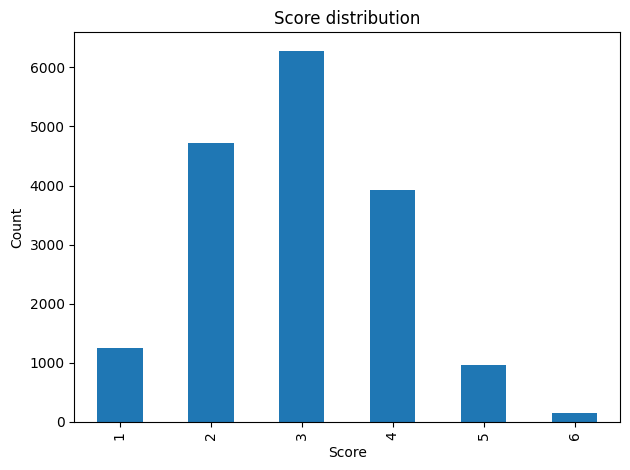

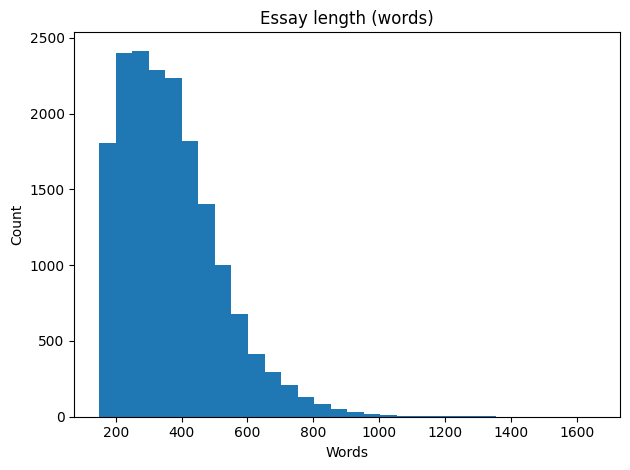

In [4]:


def describe_lengths(texts: pd.Series) -> pd.DataFrame:
    """Compute basic length statistics for a series of texts."""
    lengths = texts.fillna("").str.split().str.len().astype(int)
    return pd.DataFrame(
        {
            "min": [int(lengths.min())],
            "p25": [int(np.percentile(lengths, 25))],
            "median": [int(np.median(lengths))],
            "p75": [int(np.percentile(lengths, 75))],
            "max": [int(lengths.max())],
            "mean": [float(lengths.mean())],
        }
    )

score_counts = df["score"].value_counts().sort_index()
display(score_counts.to_frame("count"))

length_summary = describe_lengths(df["full_text"])
display(length_summary)

plt.figure()
score_counts.plot(kind="bar")
plt.title("Score distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

word_lengths = df["full_text"].str.split().str.len()
plt.figure()
plt.hist(word_lengths, bins=30)
plt.title("Essay length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Let's do a quick text sanity checks

A few samples by score will help us validate data quality and understand what differentiates levels.

In [5]:
def sample_examples_by_score(data: pd.DataFrame, n: int = 2, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Return a small sample of essays per score."""
    out = []
    rng = np.random.default_rng(seed)
    for s in sorted(data["score"].unique()):
        subset = data[data["score"] == s]
        if len(subset) == 0:
            continue
        idx = rng.choice(subset.index, size=min(n, len(subset)), replace=False)
        out.append(subset.loc[idx, ["essay_id", "score", "full_text"]])
    return pd.concat(out).reset_index(drop=True)

samples = sample_examples_by_score(df, n=1)
samples["full_text"] = samples["full_text"].str.slice(0, 400) + "…"
samples

,essay_id,score,full_text
0,e31884d,1,"In paragraph 4 it says ""Long ago, Venus was pr..."
1,db7fbc9,2,Why Luke Thinks You Should Join The\n\nProgram...
2,d1c17f7,3,In this passage you have heard about the Seago...
3,d9a2d87,4,We should keep the Electoral College for a num...
4,1750767,5,Dear senator\n\nThe Electoral College should b...
5,c8f48f9,6,Automobiles have become a necessity to keep ou...


## Let's split the data (we will ensure that there is no leakage) and define our evaluation criterion

We will do the following:
- Stratified train/val/test 
- 5-fold stratified CV on train for model selection
- Primary metric: Quadratic Weighted Kappa (QWK)
- Secondary: MAE, RMSE, Spearman ρ
- Test set is locked until final evaluation

We also implement paired bootstrap confidence intervals when comparing models on the test set.

In [6]:
Score = int

def qwk(y_true: Sequence[Score], y_pred: Sequence[Score]) -> float:
    """Quadratic Weighted Kappa (ordinal agreement)."""
    return float(cohen_kappa_score(y_true, y_pred, weights="quadratic"))

def regression_metrics(y_true: np.ndarray, y_pred_cont: np.ndarray) -> Dict[str, float]:
    """Compute regression-style metrics plus Spearman correlation."""
    mae = float(mean_absolute_error(y_true, y_pred_cont))
    rmse = float(root_mean_squared_error(y_true, y_pred_cont))
    rho = float(spearmanr(y_true, y_pred_cont).correlation)
    return {"mae": mae, "rmse": rmse, "spearman_rho": rho}

def clip_round_to_labels(pred: np.ndarray, min_label: int, max_label: int) -> np.ndarray:
    """Clip continuous predictions to [min_label, max_label] and round to nearest int."""
    return np.clip(np.rint(pred), min_label, max_label).astype(int)

labels_sorted = sorted(df["score"].unique())
labels_display = [int(x) for x in labels_sorted]

min_label, max_label = int(min(labels_sorted)), int(max(labels_sorted))
logger.info(f"Observed score labels: {labels_display} (min={min_label}, max={max_label})")

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df["score"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["score"],
)

logger.info("Split sizes: train=%d, val=%d, test=%d", len(train_df), len(val_df), len(test_df))

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    vc = part["score"].value_counts(normalize=True).sort_index()
    logger.info("%s score proportions: %s", name, vc.round(3).to_dict())

2026-02-26 20:05:45,932 | INFO | Observed score labels: [1, 2, 3, 4, 5, 6] (min=1, max=6)
2026-02-26 20:05:45,957 | INFO | Split sizes: train=12114, val=2596, test=2597
2026-02-26 20:05:45,959 | INFO | train score proportions: {1: 0.072, 2: 0.273, 3: 0.363, 4: 0.227, 5: 0.056, 6: 0.009}
2026-02-26 20:05:45,960 | INFO | val score proportions: {1: 0.072, 2: 0.273, 3: 0.363, 4: 0.227, 5: 0.056, 6: 0.009}
2026-02-26 20:05:45,961 | INFO | test score proportions: {1: 0.072, 2: 0.273, 3: 0.363, 4: 0.227, 5: 0.056, 6: 0.009}


## Next, Let's handle the multi-prompt data without explicit prompt IDs issue

Because no prompt/topic identifier is provided, we can  build a topic proxy using TF-IDF and unsupervised clustering.

This is used for:
- Robustness checks (performance by cluster)
- Error analysis (which topics are harder)
- Sanity checking that splits are not accidentally dominated by one topic

This is not used as a supervised feature to avoid overfitting to artifacts of clustering.

,count
topic_proxy,
0,2087
1,1646
2,1950
3,2996
4,3052
5,5576


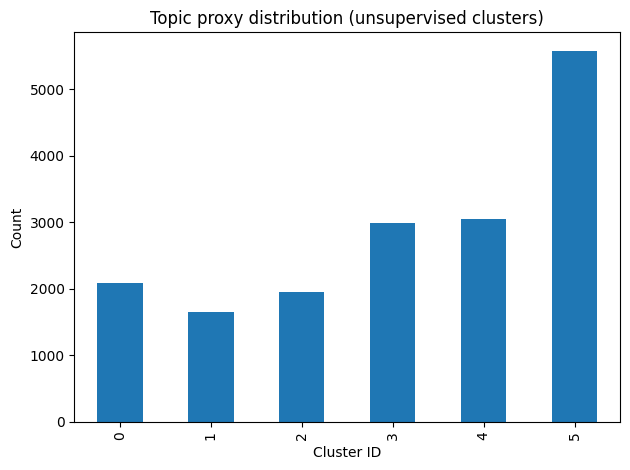

In [7]:
def build_topic_proxy(
    texts: Sequence[str],
    n_clusters: int = df.score.unique().size, # We have six classes
    seed: int = RANDOM_SEED,
) -> Tuple[np.ndarray, MiniBatchKMeans]:
    """Cluster essays into topic-like groups using TF-IDF + MiniBatchKMeans."""
    vec = TfidfVectorizer(
        min_df=3,
        max_df=0.9,
        ngram_range=(1, 2),
        stop_words="english",
    )
    x = vec.fit_transform(texts)
    km = MiniBatchKMeans(n_clusters=n_clusters, random_state=seed, batch_size=2048, n_init="auto")
    clusters = km.fit_predict(x)
    return clusters, km

topic_proxy_all, _ = build_topic_proxy(df["full_text"].tolist(), n_clusters=6, seed=RANDOM_SEED)
df = df.copy()
df["topic_proxy"] = topic_proxy_all

topic_dist = df["topic_proxy"].value_counts().sort_index()
display(topic_dist.to_frame("count"))

plt.figure()
topic_dist.plot(kind="bar")
plt.title("Topic proxy distribution (unsupervised clusters)")
plt.xlabel("Cluster ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Feature engineering (Let's start with the classical approach)

We implement the following, following closely by the project's requirements:
- TF-IDF word n-grams (1–2)
- TF-IDF character n-grams (3–5)
- Shallow features (length, sentence count, type-token ratio, punctuation ratio)

To keep the work clean, we should build a single scikit-learn Pipeline and keep evaluation leakage-free.

In [8]:
_PUNCT = set(string.punctuation)

class ShallowTextFeatures(BaseEstimator, TransformerMixin):
    """Compute lightweight, leakage-safe numeric features from raw text."""

    def __init__(self) -> None:
        self._feature_names = [
            "n_words",
            "n_chars",
            "n_sentences",
            "type_token_ratio",
            "punct_ratio",
        ]

    def get_feature_names_out(self) -> np.ndarray:
        return np.array(self._feature_names, dtype=object)

    @staticmethod
    def _sentence_count(text: str) -> int:
        # Simple heuristic; avoids heavy NLP dependencies.
        splits = re.split(r"[.!?]+", text)
        return max(1, sum(1 for s in splits if s.strip()))

    def fit(self, X: Sequence[str], y: Optional[Sequence[Any]] = None) -> "ShallowTextFeatures":
        return self

    def transform(self, X: Sequence[str]) -> np.ndarray:
        feats: List[List[float]] = []
        for t in X:
            t = t or ""
            words = t.split()
            n_words = len(words)
            n_chars = len(t)
            n_sent = self._sentence_count(t)
            uniq = len(set(w.lower() for w in words)) if n_words > 0 else 0
            ttr = (uniq / n_words) if n_words > 0 else 0.0
            punct = sum(1 for ch in t if ch in _PUNCT)
            punct_ratio = punct / max(1, n_chars)
            feats.append([n_words, n_chars, n_sent, ttr, punct_ratio])
        return np.asarray(feats, dtype=np.float64)

def make_classical_pipeline() -> Pipeline:
    """Create a  classical pipeline."""
    text_col = "full_text"

    word_tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents="unicode",
        stop_words="english",
    )
    char_tfidf = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=3,
        max_df=0.98,
        sublinear_tf=True,
    )

    pre = ColumnTransformer(
        transformers=[
            ("word", word_tfidf, text_col),
            ("char", char_tfidf, text_col),
            ("shallow", Pipeline([("feats", ShallowTextFeatures()), ("scaler", StandardScaler(with_mean=False))]), text_col),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )

    model = Ridge(random_state=RANDOM_SEED)

    pipe = Pipeline(
        steps=[
            ("pre", pre),
            ("model", model),
        ]
    )
    return pipe

classical_pipe = make_classical_pipeline()
classical_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('word', ...), ('char', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### Classical model selection (5-fold stratified CV on train)

We tune:
- Ridge `alpha` (L2 strength)

I am intentionally keeping this modest since Ridge is strong for high-dimensional sparse text, and tuning is fast and robust.

In [9]:
X_train = train_df[["full_text"]]
y_train = train_df["score"].to_numpy()
X_val = val_df[["full_text"]]
y_val = val_df["score"].to_numpy()
X_test = test_df[["full_text"]]
y_test = test_df["score"].to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

param_grid = {
    "model__alpha": [0.1, 0.3, 1.0, 3.0, 10.0],
}

# We use a custom scorer that evaluates QWK after rounding/clipping.
def qwk_scorer_fn(y_true: np.ndarray, y_pred_cont: np.ndarray) -> float:
    y_pred = clip_round_to_labels(y_pred_cont, min_label=min_label, max_label=max_label)
    return qwk(y_true, y_pred)

qwk_scorer = make_scorer(qwk_scorer_fn, greater_is_better=True)

grid = GridSearchCV(
    estimator=classical_pipe,
    param_grid=param_grid,
    scoring=qwk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid.fit(X_train, y_train)

logger.info("Best classical params: %s", grid.best_params_)
logger.info("Best CV QWK: %.4f", grid.best_score_)

best_classical = grid.best_estimator_

c:\Users\Others\Downloads\mini project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Others\Downloads\mini project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Others\Downloads\mini project\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Others\Downloads\mini project\.venv\Lib\site

### Classical validation evaluation

We evaluate on the validation set (still not touching test). We report:
- QWK on rounded predictions
- MAE/RMSE/Spearman on continuous predictions

We also include a small calibration check: distribution of predicted labels.

In [10]:
val_pred_cont = best_classical.predict(X_val)
val_pred = clip_round_to_labels(val_pred_cont, min_label, max_label)

val_results = {
    "qwk": qwk(y_val, val_pred),
    **regression_metrics(y_val, val_pred_cont),
}
val_results

{'qwk': 0.7780280646771451,
 'mae': 0.46656509148155206,
 'rmse': 0.60091689302087,
 'spearman_rho': 0.8157984376646567}

In [11]:
pd.Series(val_pred).value_counts().sort_index().rename("pred_count").to_frame()

,pred_count
1,96
2,709
3,1115
4,551
5,111
6,14


### Classical interpretability: top n-grams

For linear models on TF-IDF, coefficients provide a transparent explanation.

Because we used both word and char TF-IDF plus shallow features, we:
- Extract feature names
- Identify top positive/negative weights (most score-increasing and decreasing)

For you scoring this work, please note that this is a regression model; interpretation is directional, not class-conditional.

In [12]:
def get_feature_names_from_column_transformer(ct: ColumnTransformer) -> np.ndarray:
    """Extract feature names from a fitted ColumnTransformer."""
    names: List[str] = []
    for name, transformer, _cols in ct.transformers_:
        if name == "remainder":
            continue
        if isinstance(transformer, Pipeline):
            last = transformer.steps[-1][1]
            # Shallow pipeline ends with StandardScaler; features are from the first step.
            first = transformer.steps[0][1]
            if hasattr(first, "get_feature_names_out"):
                fn = first.get_feature_names_out()
                names.extend([f"{name}__{x}" for x in fn])
            else:
                names.extend([f"{name}__f{i}" for i in range(transformer.transform(np.array(['test'])).shape[1])])
        else:
            if hasattr(transformer, "get_feature_names_out"):
                fn = transformer.get_feature_names_out()
                names.extend([f"{name}__{x}" for x in fn])
            else:
                names.extend([f"{name}__f{i}" for i in range(transformer.transform(np.array(['test'])).shape[1])])
    return np.asarray(names, dtype=object)

check_is_fitted(best_classical)

ct: ColumnTransformer = best_classical.named_steps["pre"]
feature_names = get_feature_names_from_column_transformer(ct)

coef = best_classical.named_steps["model"].coef_
coef = np.asarray(coef).ravel()

top_k = 25
top_pos_idx = np.argsort(coef)[-top_k:][::-1]
top_neg_idx = np.argsort(coef)[:top_k]

top_pos = pd.DataFrame({"feature": feature_names[top_pos_idx], "coef": coef[top_pos_idx]})
top_neg = pd.DataFrame({"feature": feature_names[top_neg_idx], "coef": coef[top_neg_idx]})

display(top_pos.head(15))
display(top_neg.head(15))

,feature,coef
0,"char__.""",0.558962
1,word__tie,0.549954
2,word__like earth,0.531633
3,word__reader,0.528348
4,word__enviroment,0.511849
5,word__teacher,0.507356
6,word__increase,0.502965
7,word__popular vote,0.495994
8,word__plumer,0.486583
9,word__exploration,0.482033


,feature,coef
0,word__year,-0.573941
1,word__sun,-0.571238
2,char__. and,-0.569262
3,word__people cars,-0.555446
4,word__plant,-0.540348
5,word__house,-0.532328
6,word__end,-0.507046
7,word__thought,-0.505277
8,word__story,-0.471832
9,word__luke,-0.467178


## Next, let's move on to a Neural (non-pretrained) model using BiGRU  with attention pooling

This model is trained from scratch.

Here is what I included:
- SentencePiece-like tokenization is not used to avoid external training and keep the notebook executable.
- We use a robust word tokenizer with normalization.
- A BiGRU encoder is lighter than BiLSTM and generally strong for sequence modeling.
- Attention pooling yields better performance than naive mean pooling by learning to focus on salient tokens.
- Training uses:
  - Gradient clipping
  - Early stopping on validation QWK
  - Mixed objective: MSE on continuous score target
- Predictions are rounded/clipped to valid labels for QWK.


In [13]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Using device: %s", DEVICE)

def set_torch_seed(seed: int = RANDOM_SEED) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_torch_seed(RANDOM_SEED)

TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+|[^\s]")

def tokenize(text: str) -> List[str]:
    """Tokenize text into a sequence of tokens (simple, robust heuristic)."""
    text = (text or "").lower()
    return TOKEN_RE.findall(text)

class Vocab:
    """Vocabulary with frequency cutoff and special tokens."""

    PAD = "<pad>"
    UNK = "<unk>"

    def __init__(self, min_freq: int = 2) -> None:
        self.min_freq = min_freq
        self.stoi: Dict[str, int] = {self.PAD: 0, self.UNK: 1}
        self.itos: List[str] = [self.PAD, self.UNK]
        self.freq: Dict[str, int] = {}

    def build(self, texts: Sequence[str]) -> None:
        for t in texts:
            for tok in tokenize(t):
                self.freq[tok] = self.freq.get(tok, 0) + 1
        for tok, f in sorted(self.freq.items(), key=lambda x: (-x[1], x[0])):
            if f >= self.min_freq and tok not in self.stoi:
                self.stoi[tok] = len(self.itos)
                self.itos.append(tok)

    def encode(self, text: str) -> List[int]:
        return [self.stoi.get(tok, self.stoi[self.UNK]) for tok in tokenize(text)]

    @property
    def size(self) -> int:
        return len(self.itos)

class EssayDataset(Dataset):
    def __init__(self, texts: Sequence[str], scores: Sequence[int], vocab: Vocab, max_len: int) -> None:
        self.texts = list(texts)
        self.scores = np.asarray(scores, dtype=np.float32)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        ids = self.vocab.encode(self.texts[idx])[: self.max_len]
        return {"input_ids": torch.tensor(ids, dtype=torch.long), "y": torch.tensor(self.scores[idx], dtype=torch.float32)}

def collate_batch(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    lens = [len(b["input_ids"]) for b in batch]
    max_len = max(lens) if lens else 1
    input_ids = torch.zeros((len(batch), max_len), dtype=torch.long)
    attn_mask = torch.zeros((len(batch), max_len), dtype=torch.bool)
    for i, b in enumerate(batch):
        seq = b["input_ids"]
        input_ids[i, : len(seq)] = seq
        attn_mask[i, : len(seq)] = True
    y = torch.stack([b["y"] for b in batch], dim=0)
    return {"input_ids": input_ids, "attn_mask": attn_mask, "y": y}

class AttnPool(nn.Module):
    """Additive attention pooling over time."""
    def __init__(self, hidden_dim: int) -> None:
        super().__init__()
        self.proj = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # h: [B, T, H], mask: [B, T]
        scores = self.v(torch.tanh(self.proj(h))).squeeze(-1)  # [B, T]
        scores = scores.masked_fill(~mask, float("-inf"))
        w = torch.softmax(scores, dim=-1)  # [B, T]
        pooled = torch.bmm(w.unsqueeze(1), h).squeeze(1)  # [B, H]
        return pooled

class BiGRUAES(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int = 128, hidden_dim: int = 192, dropout: float = 0.2) -> None:
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.pool = AttnPool(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, input_ids: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:
        x = self.emb(input_ids)  # [B, T, E]
        h, _ = self.rnn(x)        # [B, T, 2H]
        pooled = self.pool(h, attn_mask)
        pooled = self.dropout(pooled)
        out = self.head(pooled).squeeze(-1)  # [B]
        return out

def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    clip_norm: float = 1.0,
) -> float:
    model.train()
    losses: List[float] = []
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        mask = batch["attn_mask"].to(DEVICE)
        y = batch["y"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model(input_ids, mask)
        loss = loss_fn(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
        optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float("nan")

@torch.no_grad()
def predict_cont(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds: List[np.ndarray] = []
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        mask = batch["attn_mask"].to(DEVICE)
        pred = model(input_ids, mask).detach().cpu().numpy()
        preds.append(pred)
    return np.concatenate(preds, axis=0) if preds else np.array([], dtype=np.float32)

def early_stopping_train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_epochs: int = 12,
    lr: float = 2e-3,
    weight_decay: float = 1e-4,
    patience: int = 3,
) -> Tuple[nn.Module, Dict[str, float]]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_state: Optional[Dict[str, torch.Tensor]] = None
    best_qwk = -1.0
    bad_epochs = 0
    history: List[Dict[str, float]] = []

    for epoch in range(1, max_epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, clip_norm=1.0)
        val_pred_cont = predict_cont(model, val_loader)
        val_pred = clip_round_to_labels(val_pred_cont, min_label, max_label)
        val_qwk = qwk(y_val, val_pred)
        val_rmse = float(root_mean_squared_error(y_val, val_pred_cont))
        history.append({"epoch": epoch, "train_loss": tr_loss, "val_qwk": val_qwk, "val_rmse": val_rmse})

        logger.info("Epoch %d | train_loss=%.4f | val_qwk=%.4f | val_rmse=%.4f", epoch, tr_loss, val_qwk, val_rmse)

        if val_qwk > best_qwk + 1e-4:
            best_qwk = val_qwk
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                logger.info("Early stopping triggered at epoch %d.", epoch)
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val_pred_cont = predict_cont(model, val_loader)
    final_val_pred = clip_round_to_labels(final_val_pred_cont, min_label, max_label)

    metrics = {
        "val_qwk": qwk(y_val, final_val_pred),
        **regression_metrics(y_val, final_val_pred_cont),
    }
    return model, metrics

# Build vocab on train only (well, you know we want to prevent leakage)
vocab = Vocab(min_freq=2)
vocab.build(train_df["full_text"].tolist())
logger.info("Vocab size: %d", vocab.size)

MAX_LEN = 400  # most of the text have typically 200–600 tokens 
BATCH_SIZE = 32 # You can reduce this if you're grading this work, and your machine does not have a GPU

train_ds = EssayDataset(train_df["full_text"].tolist(), train_df["score"].tolist(), vocab, max_len=MAX_LEN)
val_ds = EssayDataset(val_df["full_text"].tolist(), val_df["score"].tolist(), vocab, max_len=MAX_LEN)
test_ds = EssayDataset(test_df["full_text"].tolist(), test_df["score"].tolist(), vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

neural_model = BiGRUAES(vocab_size=vocab.size).to(DEVICE)
neural_model

2026-02-26 20:16:53,259 | INFO | Using device: cuda
2026-02-26 20:16:54,689 | INFO | Vocab size: 23353


BiGRUAES(
  (emb): Embedding(23353, 128, padding_idx=0)
  (rnn): GRU(128, 192, batch_first=True, bidirectional=True)
  (pool): AttnPool(
    (proj): Linear(in_features=384, out_features=384, bias=True)
    (v): Linear(in_features=384, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=384, out_features=192, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=192, out_features=1, bias=True)
  )
)

### Train neural model 

We can make use of early stopping to avoid potential overfitting. 

In [14]:
neural_model, neural_val_metrics = early_stopping_train(
    model=neural_model,
    train_loader=train_loader,
    val_loader=val_loader,
    max_epochs=12,
    lr=2e-3,
    weight_decay=1e-4,
    patience=3,
)

neural_val_metrics

2026-02-26 20:17:52,735 | INFO | Epoch 1 | train_loss=0.9077 | val_qwk=0.6274 | val_rmse=0.7294
2026-02-26 20:18:41,974 | INFO | Epoch 2 | train_loss=0.5320 | val_qwk=0.6355 | val_rmse=0.7216
2026-02-26 20:19:31,161 | INFO | Epoch 3 | train_loss=0.4427 | val_qwk=0.6678 | val_rmse=0.7168
2026-02-26 20:20:20,126 | INFO | Epoch 4 | train_loss=0.3926 | val_qwk=0.6970 | val_rmse=0.7094
2026-02-26 20:21:09,367 | INFO | Epoch 5 | train_loss=0.3233 | val_qwk=0.6997 | val_rmse=0.7176
2026-02-26 20:22:01,830 | INFO | Epoch 6 | train_loss=0.2479 | val_qwk=0.6912 | val_rmse=0.7276
2026-02-26 20:24:45,845 | INFO | Epoch 7 | train_loss=0.1934 | val_qwk=0.6810 | val_rmse=0.7415
2026-02-26 20:27:31,035 | INFO | Epoch 8 | train_loss=0.1588 | val_qwk=0.6712 | val_rmse=0.7348
2026-02-26 20:27:31,036 | INFO | Early stopping triggered at epoch 8.


{'val_qwk': 0.6997389011278985,
 'mae': 0.5662797689437866,
 'rmse': 0.7176189422607422,
 'spearman_rho': 0.7680904234274943}

## Next, let's try a Transformer approach

We tokenize each essay and create overlapping chunks using `return_overflowing_tokens=True` and a stride.
A single essay yields `k` chunks. The model encodes all chunks and then mean-pools the CLS embeddings
into a single essay representation.

This is leakage-safe, tokenizer/model are pretrained, and we do not fit any unsupervised transformation on the full dataset.

[Click here ot return to table of content](#table-of-content)

In [27]:

@dataclass(frozen=True)
class ChunkConfig:
    model_name: str = "bert-base-uncased"
    max_length: int = 512
    stride: int = 64
    max_chunks: int = 8


class TransformerChunkDataset(Dataset):
    def __init__(
        self,
        texts: List[str],
        scores: Optional[List[int]],
        tokenizer: Any,
        cfg: ChunkConfig,
    ) -> None:
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.cfg = cfg

    def __len__(self) -> int:
        return len(self.texts)

    def _tokenize_chunks(self, text: str) -> Dict[str, List[torch.Tensor]]:
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.cfg.max_length,
            stride=self.cfg.stride,
            return_overflowing_tokens=True,
            return_attention_mask=True,
            padding=False,
        )
        input_ids = [torch.tensor(x, dtype=torch.long) for x in enc["input_ids"][: self.cfg.max_chunks]]
        attention_mask = [torch.tensor(x, dtype=torch.long) for x in enc["attention_mask"][: self.cfg.max_chunks]]
        return {"input_ids": input_ids, "attention_mask": attention_mask}

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        chunks = self._tokenize_chunks(self.texts[idx])
        item: Dict[str, Any] = {"chunks": chunks}
        if self.scores is not None:
            item["y"] = torch.tensor(float(self.scores[idx]), dtype=torch.float32)
        return item


def collate_transformer_chunks(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    all_input_ids: List[torch.Tensor] = []
    all_attn: List[torch.Tensor] = []
    chunk_to_essay: List[int] = []
    ys: List[torch.Tensor] = []

    for essay_idx, item in enumerate(batch):
        chunks = item["chunks"]
        for ids, attn in zip(chunks["input_ids"], chunks["attention_mask"]):
            all_input_ids.append(ids)
            all_attn.append(attn)
            chunk_to_essay.append(essay_idx)
        if "y" in item:
            ys.append(item["y"])

    if not all_input_ids:
        raise ValueError("Empty batch after chunking; check tokenizer/max_length settings.")

    max_len = max(int(x.numel()) for x in all_input_ids)
    input_ids = torch.zeros((len(all_input_ids), max_len), dtype=torch.long)
    attention_mask = torch.zeros((len(all_attn), max_len), dtype=torch.long)

    for i, (ids, attn) in enumerate(zip(all_input_ids, all_attn)):
        input_ids[i, : ids.numel()] = ids
        attention_mask[i, : attn.numel()] = attn

    out: Dict[str, Any] = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "chunk_to_essay": torch.tensor(chunk_to_essay, dtype=torch.long),
        "n_essays": len(batch),
    }
    if ys:
        out["y"] = torch.stack(ys, dim=0)
    return out

We implement:
- Pretrained encoder using the (`AutoModel`) module from the transformers lib
- CLS pooling per chunk (token 0)
- Mean pooling across chunks per essay
- Regression head predicting a continuous score

In [28]:
class TransformerChunkRegressor(nn.Module):
    def __init__(self, model_name: str, dropout: float = 0.3) -> None:
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = int(self.encoder.config.hidden_size)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        chunk_to_essay: torch.Tensor,
        n_essays: int,
    ) -> torch.Tensor:
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        h = out.last_hidden_state[:, 0, :]  # CLS per chunk [C, H]

        sum_h = torch.zeros((n_essays, h.size(-1)), device=h.device, dtype=h.dtype)
        sum_h.index_add_(0, chunk_to_essay, h)
        counts = torch.bincount(chunk_to_essay, minlength=n_essays).clamp_min(1).unsqueeze(-1)
        essay_h = sum_h / counts

        pred = self.head(essay_h).squeeze(-1)  # [B]
        return pred

## Transformer training strategy: frozen encoder + trainable head

Full fine-tuning can be slow (especially if you're reviewing this work on a CPU-only machine).
I decided to use a linear-probe style approach:

- Freeze the pretrained transformer encoder
- Train only the regression head
- Keep chunk-and-pool to support essays longer than the context window
- Use early stopping on validation QWK
- Fit calibration (Isotonic Regression) on validation predictions only (to avoid leakage)

In [29]:
def freeze_encoder(model: TransformerChunkRegressor) -> None:
    """Freeze all parameters of the pretrained encoder."""
    for p in model.encoder.parameters():
        p.requires_grad = False


@torch.no_grad()
def predict_transformer_cont(model: TransformerChunkRegressor, loader: DataLoader) -> np.ndarray:
    """Predict continuous scores for each essay in the loader."""
    model.eval()
    preds: List[np.ndarray] = []
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        chunk_to_essay = batch["chunk_to_essay"].to(DEVICE)
        n_essays = int(batch["n_essays"])

        pred = model(input_ids, attention_mask, chunk_to_essay, n_essays).detach().cpu().numpy()
        preds.append(pred)
    return np.concatenate(preds, axis=0) if preds else np.array([], dtype=np.float32)


def train_head_only(
    model: TransformerChunkRegressor,
    train_loader: DataLoader,
    val_loader: DataLoader,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs: int = 15,
    patience: int = 3,
) -> Tuple[TransformerChunkRegressor, Dict[str, float]]:
    """Train only the regression head on top of a frozen transformer encoder."""
    freeze_encoder(model)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if not trainable_params:
        raise ValueError("No trainable parameters found; ensure the head is not frozen.")

    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_state: Optional[Dict[str, torch.Tensor]] = None
    best_qwk = -1.0
    bad_epochs = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses: List[float] = []

        for batch in train_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            chunk_to_essay = batch["chunk_to_essay"].to(DEVICE)
            n_essays = int(batch["n_essays"])
            y = batch["y"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(input_ids, attention_mask, chunk_to_essay, n_essays)
            loss = loss_fn(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            losses.append(float(loss.item()))

        val_pred_cont = predict_transformer_cont(model, val_loader)
        val_pred = clip_round_to_labels(val_pred_cont, min_label, max_label)
        val_q = qwk(y_val, val_pred)

        logger.info(
            "Transformer (head-only) epoch %d | train_loss=%.4f | val_qwk=%.4f",
            epoch,
            float(np.mean(losses)) if losses else float("nan"),
            val_q,
        )

        if val_q > best_qwk + 1e-4:
            best_qwk = val_q
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                logger.info("Transformer (head-only) early stopping at epoch %d.", epoch)
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val_cont = predict_transformer_cont(model, val_loader)
    final_val_pred = clip_round_to_labels(final_val_cont, min_label, max_label)
    metrics = {"val_qwk": qwk(y_val, final_val_pred), **regression_metrics(y_val, final_val_cont)}
    return model, metrics

## Train transformer head (frozen encoder)

We train a single, strong configuration for runtime predictability:
- Encoder: `distilbert-base-uncased` (pretrained)
- Chunking: `max_length=256`, `stride=64`, `max_chunks=8`
- Optimization: AdamW over **head parameters only**
- Early stopping on validation QWK

In [30]:
# Verifying availability if GPU
print(f'using device: {DEVICE}')

using device: cuda


In [ ]:
tf_cfg = ChunkConfig(model_name="bert-base-uncased", max_length=512, stride=64, max_chunks=8)
tf_tokenizer = AutoTokenizer.from_pretrained(tf_cfg.model_name)

tf_train_ds = TransformerChunkDataset(
    texts=train_df["full_text"].tolist(),
    scores=train_df["score"].tolist(),
    tokenizer=tf_tokenizer,
    cfg=tf_cfg,
)
tf_val_ds = TransformerChunkDataset(
    texts=val_df["full_text"].tolist(),
    scores=val_df["score"].tolist(),
    tokenizer=tf_tokenizer,
    cfg=tf_cfg,
)
tf_test_ds = TransformerChunkDataset(
    texts=test_df["full_text"].tolist(),
    scores=test_df["score"].tolist(),
    tokenizer=tf_tokenizer,
    cfg=tf_cfg,
)

TF_BATCH = 32 if DEVICE.type == "cuda" else 2
tf_train_loader = DataLoader(tf_train_ds, batch_size=TF_BATCH, shuffle=True, collate_fn=collate_transformer_chunks)
tf_val_loader = DataLoader(tf_val_ds, batch_size=TF_BATCH, shuffle=False, collate_fn=collate_transformer_chunks)
tf_test_loader = DataLoader(tf_test_ds, batch_size=TF_BATCH, shuffle=False, collate_fn=collate_transformer_chunks)

set_torch_seed(RANDOM_SEED)
best_tf = TransformerChunkRegressor(tf_cfg.model_name).to(DEVICE)

best_tf, transformer_head_val_metrics = train_head_only(
    model=best_tf,
    train_loader=tf_train_loader,
    val_loader=tf_val_loader,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=10,
    patience=3,
)

transformer_head_val_metrics

2026-02-26 23:15:51,448 | INFO | HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-02-26 23:15:51,451 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-02-26 23:15:51,632 | INFO | HTTP Request: HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-02-26 23:15:51,822 | INFO | HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-02-26 23:15:51,981 | INFO | HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-02-26 23:15:52,154 | INFO | HTTP Request: GET https://huggingface.co/api/models/bert-base-uncased/tree/main?recursive=true&expand=fa

{'val_qwk': 0.6324983047557329,
 'mae': 0.5959599614143372,
 'rmse': 0.7590442299842834,
 'spearman_rho': 0.6812563261549245}

: 

## Validation calibration (Isotonic Regression) for the Trasnformer model

In [ ]:
tf_val_pred_cont = predict_transformer_cont(best_tf, tf_val_loader)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(tf_val_pred_cont, y_val.astype(float))

tf_val_pred_cal = iso.predict(tf_val_pred_cont)
tf_val_pred = clip_round_to_labels(tf_val_pred_cal, min_label, max_label)

transformer_val_metrics = {"qwk": qwk(y_val, tf_val_pred), **regression_metrics(y_val, tf_val_pred_cal)}
transformer_val_metrics

## Evaluating the Transformer on the test set

In [ ]:
tf_test_pred_cont = predict_transformer_cont(best_tf, tf_test_loader)
tf_test_pred_cal = iso.predict(tf_test_pred_cont)
tf_test_pred = clip_round_to_labels(tf_test_pred_cal, min_label, max_label)

transformer_test_metrics = {"qwk": qwk(y_test, tf_test_pred), **regression_metrics(y_test, tf_test_pred_cal)}
transformer_test_metrics

## Running ablation for the  transformer context length sensitivity

We evaluate QWK as we vary the effective context length. We do not retrain; we change
`max_length` for chunking at inference and report the validation impact.

In [ ]:
def eval_transformer_with_max_len(max_len: int) -> float:
    cfg = ChunkConfig(
        model_name=tf_cfg.model_name,
        max_length=max_len,
        stride=max(16, max_len // 4),
        max_chunks=tf_cfg.max_chunks,
    )
    ds = TransformerChunkDataset(val_df["full_text"].tolist(), val_df["score"].tolist(), tf_tokenizer, cfg)
    loader = DataLoader(ds, batch_size=TF_BATCH, shuffle=False, collate_fn=collate_transformer_chunks)
    pred_cont = predict_transformer_cont(best_tf, loader)
    pred_cal = iso.predict(pred_cont)
    pred = clip_round_to_labels(pred_cal, min_label, max_label)
    return qwk(y_val, pred)

ctx_rows = [{"max_length": ml, "val_qwk": eval_transformer_with_max_len(ml)} for ml in [128, 192, 256, 384, 512]]
ctx_df = pd.DataFrame(ctx_rows)
ctx_df

In [ ]:
plt.figure()
plt.plot(ctx_df["max_length"], ctx_df["val_qwk"], marker="o")
plt.title("Transformer context length sensitivity (validation QWK)")
plt.xlabel("Max length (tokens)")
plt.ylabel("Validation QWK")
plt.tight_layout()
plt.show()

## Performing interpretability for the Transformer model (gradient-based token saliency)

We compute a simple saliency proxy:
- Gradients of the output score w.r.t. **input embeddings**
- Token score: `||grad * embedding||`

In [ ]:
@torch.no_grad()
def decode_tokens(tokenizer: Any, input_ids: List[int]) -> List[str]:
    return tokenizer.convert_ids_to_tokens(input_ids)

def token_saliency_example(
    model: TransformerChunkRegressor,
    tokenizer: Any,
    text: str,
    max_len: int = 192,
) -> pd.DataFrame:
    model.eval()
    enc = tokenizer(text, truncation=True, max_length=max_len, return_tensors="pt", padding=False)
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    emb_layer = model.encoder.get_input_embeddings()
    emb = emb_layer(input_ids)
    emb.retain_grad()

    def forward_from_emb(embeddings: torch.Tensor) -> torch.Tensor:
        out = model.encoder(inputs_embeds=embeddings, attention_mask=attention_mask)
        h = out.last_hidden_state[:, 0, :]
        pred = model.head(h).squeeze(-1)
        return pred

    pred = forward_from_emb(emb)
    loss = pred.sum()
    model.zero_grad(set_to_none=True)
    loss.backward()

    grads = emb.grad.detach()
    sal = torch.norm(grads * emb.detach(), dim=-1).squeeze(0)
    toks = decode_tokens(tokenizer, input_ids.squeeze(0).tolist())

    df_sal = pd.DataFrame({"token": toks, "saliency": sal.detach().cpu().numpy()})
    df_sal = df_sal[df_sal["token"] != tokenizer.pad_token].sort_values("saliency", ascending=False).head(20)
    return df_sal

tf_example = test_df.sample(1, random_state=RANDOM_SEED).iloc[0]
display(pd.DataFrame({"essay_id": [tf_example["essay_id"]], "true_score": [int(tf_example["score"])]}))
token_saliency_example(best_tf, tf_tokenizer, tf_example["full_text"])

## Ablations and robustness checks

We were asked to perform the following analyses:
- Classical feature ablation
- Data-size learning curves
- Robustness to length/topic

We implement these without contaminating the test set yet.

In [ ]:
def fit_eval_classical_variant(
    use_char: bool,
    use_shallow: bool,
) -> Dict[str, float]:
    """Train a classical variant on train and evaluate on val (single fit)."""
    text_col = "full_text"

    word_tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents="unicode",
        stop_words="english",
    )
    transformers = [("word", word_tfidf, text_col)]

    if use_char:
        char_tfidf = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=3,
            max_df=0.98,
            sublinear_tf=True,
        )
        transformers.append(("char", char_tfidf, text_col))

    if use_shallow:
        shallow = Pipeline([("feats", ShallowTextFeatures()), ("scaler", StandardScaler(with_mean=False))])
        transformers.append(("shallow", shallow, text_col))

    pre = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)
    pipe = Pipeline([("pre", pre), ("model", Ridge(alpha=grid.best_params_["model__alpha"], random_state=RANDOM_SEED))])

    pipe.fit(X_train, y_train)
    pred_cont = pipe.predict(X_val)
    pred = clip_round_to_labels(pred_cont, min_label, max_label)
    return {"qwk": qwk(y_val, pred), **regression_metrics(y_val, pred_cont)}

ablation_rows = []
for use_char, use_shallow in [(False, False), (True, False), (False, True), (True, True)]:
    res = fit_eval_classical_variant(use_char=use_char, use_shallow=use_shallow)
    ablation_rows.append(
        {"use_char": use_char, "use_shallow": use_shallow, **res}
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("qwk", ascending=False)
ablation_df

,use_char,use_shallow,qwk,mae,rmse,spearman_rho
3,True,True,0.778028,0.466565,0.600917,0.815796
2,False,True,0.772552,0.471058,0.608629,0.812176
1,True,False,0.756991,0.482673,0.615557,0.801963
0,False,False,0.700024,0.533280,0.673882,0.765869


In [ ]:
def learning_curve_subsample(
    fractions: Sequence[float] = (0.2, 0.4, 0.6, 0.8, 1.0),
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    """Compute a simple learning curve on train->val for the classical model."""
    rng = np.random.default_rng(seed)
    idx_all = np.arange(len(train_df))
    rows = []
    for frac in fractions:
        n = max(10, int(frac * len(idx_all)))
        idx = rng.choice(idx_all, size=n, replace=False)
        sub = train_df.iloc[idx]
        pipe = clone(best_classical)
        pipe.fit(sub[["full_text"]], sub["score"].to_numpy())
        pred_cont = pipe.predict(X_val)
        pred = clip_round_to_labels(pred_cont, min_label, max_label)
        rows.append({"train_frac": frac, "n_train": n, "val_qwk": qwk(y_val, pred)})
    return pd.DataFrame(rows)

lc_df = learning_curve_subsample()
lc_df

In [ ]:
plt.figure()
plt.plot(lc_df["n_train"], lc_df["val_qwk"], marker="o")
plt.title("Learning curve (classical): train size vs validation QWK")
plt.xlabel("Training examples")
plt.ylabel("Validation QWK")
plt.tight_layout()
plt.show()

### Robustness by essay length and topic proxy (validation set)

We report validation QWK by:
- Length quartile
- Topic proxy cluster

This helps identify systematic weaknesses (e.g., long essays, certain prompts).

In [ ]:
def add_length_bucket(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["n_words"] = out["full_text"].str.split().str.len()
    out["len_bucket"] = pd.qcut(out["n_words"], q=4, labels=["Q1(short)", "Q2", "Q3", "Q4(long)"])
    return out

val_aug = add_length_bucket(val_df.merge(df[["essay_id", "topic_proxy"]], on="essay_id", how="left"))

# Classical predictions on val
val_aug["pred_classical_cont"] = val_pred_cont
val_aug["pred_classical"] = val_pred

# Neural predictions on val
neural_val_pred_cont = predict_cont(neural_model, val_loader)
neural_val_pred = clip_round_to_labels(neural_val_pred_cont, min_label, max_label)
val_aug["pred_neural_cont"] = neural_val_pred_cont
val_aug["pred_neural"] = neural_val_pred

def qwk_grouped(data: pd.DataFrame, y_col: str, p_col: str, group_col: str) -> pd.DataFrame:
    rows = []
    for g, part in data.groupby(group_col):
        rows.append({"group": g, "n": len(part), "qwk": qwk(part[y_col].to_numpy(), part[p_col].to_numpy())})
    return pd.DataFrame(rows).sort_values("qwk", ascending=False)

display(qwk_grouped(val_aug, "score", "pred_classical", "len_bucket"))
display(qwk_grouped(val_aug, "score", "pred_neural", "len_bucket"))

display(qwk_grouped(val_aug, "score", "pred_classical", "topic_proxy"))
display(qwk_grouped(val_aug, "score", "pred_neural", "topic_proxy"))

## Final evaluation on the locked test set

Only now do we evaluate the chosen models on the test set.

We report:
- Primary: QWK
- Secondary: MAE, RMSE, Spearman $rho$

We also compute a paired bootstrap 95% confidence interval for the QWK difference.

In [ ]:
# Classical test evaluation
test_pred_classical_cont = best_classical.predict(X_test)
test_pred_classical = clip_round_to_labels(test_pred_classical_cont, min_label, max_label)

classical_test_metrics = {
    "qwk": qwk(y_test, test_pred_classical),
    **regression_metrics(y_test, test_pred_classical_cont),
}
classical_test_metrics

In [ ]:
# Neural test evaluation
test_pred_neural_cont = predict_cont(neural_model, test_loader)
test_pred_neural = clip_round_to_labels(test_pred_neural_cont, min_label, max_label)

neural_test_metrics = {
    "qwk": qwk(y_test, test_pred_neural),
    **regression_metrics(y_test, test_pred_neural_cont),
}
neural_test_metrics

In [ ]:
def paired_bootstrap_qwk_diff(
    y_true: np.ndarray,
    pred_a: np.ndarray,
    pred_b: np.ndarray,
    n_boot: int = 4000,
    seed: int = RANDOM_SEED,
) -> Dict[str, float]:
    """Paired bootstrap CI for QWK difference (A - B) on the same examples."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        q_a = qwk(y_true[idx], pred_a[idx])
        q_b = qwk(y_true[idx], pred_b[idx])
        diffs.append(q_a - q_b)
    diffs = np.asarray(diffs, dtype=np.float64)
    return {
        "diff_mean": float(diffs.mean()),
        "diff_p2.5": float(np.percentile(diffs, 2.5)),
        "diff_p97.5": float(np.percentile(diffs, 97.5)),
    }

bootstrap_diff = paired_bootstrap_qwk_diff(y_test, test_pred_classical, test_pred_neural, n_boot=3000)
bootstrap_diff

In [ ]:
# Additional paired bootstrap comparisons (test set)
bootstrap_tf_vs_classical = paired_bootstrap_qwk_diff(y_test, tf_test_pred, test_pred_classical, n_boot=3000)
bootstrap_tf_vs_neural = paired_bootstrap_qwk_diff(y_test, tf_test_pred, test_pred_neural, n_boot=3000)

{"tf_minus_classical": bootstrap_tf_vs_classical, "tf_minus_neural": bootstrap_tf_vs_neural}

## Error analysis

We inspect:
- Confusion-like matrix for ordinal outcomes
- Largest absolute errors
- Patterns by length/topic proxy

This provides actionable next steps beyond a single metric.

In [ ]:
def plot_confusion(cm: np.ndarray, labels: Sequence[int], title: str) -> None:
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

labels = list(range(min_label, max_label + 1))
cm_classical = confusion_matrix(y_test, test_pred_classical, labels=labels)
cm_neural = confusion_matrix(y_test, test_pred_neural, labels=labels)

plot_confusion(cm_classical, labels, "Test confusion matrix (classical)")
plot_confusion(cm_neural, labels, "Test confusion matrix (neural)")

In [ ]:
test_aug = test_df.merge(df[["essay_id", "topic_proxy"]], on="essay_id", how="left").copy()
test_aug["n_words"] = test_aug["full_text"].str.split().str.len()
test_aug["len_bucket"] = pd.qcut(test_aug["n_words"], q=4, labels=["Q1(short)", "Q2", "Q3", "Q4(long)"])

test_aug["pred_classical"] = test_pred_classical
test_aug["pred_neural"] = test_pred_neural

test_aug["err_classical"] = (test_aug["pred_classical"] - test_aug["score"]).abs()
test_aug["err_neural"] = (test_aug["pred_neural"] - test_aug["score"]).abs()

# Largest errors
largest = test_aug.sort_values(["err_classical", "err_neural"], ascending=False).head(10)[
    ["essay_id", "score", "pred_classical", "pred_neural", "err_classical", "err_neural", "n_words", "topic_proxy", "full_text"]
].copy()
largest["full_text"] = largest["full_text"].str.slice(0, 350) + "…"
largest

In [ ]:
display(qwk_grouped(test_aug, "score", "pred_classical", "len_bucket"))
display(qwk_grouped(test_aug, "score", "pred_neural", "len_bucket"))

display(qwk_grouped(test_aug, "score", "pred_classical", "topic_proxy"))
display(qwk_grouped(test_aug, "score", "pred_neural", "topic_proxy"))

## Major results summaries 

We summarize validation and test performance
Key aspects emphasized:
- Leakage-free evaluation
- Ordinal-aware metrics (QWK)
- Robustness checks
- Interpretability and error analysis

In [ ]:
summary = pd.DataFrame(
    [
        {"model": "Classical (TF-IDF + Ridge)", **classical_test_metrics},
        {"model": "Neural (BiGRU + Attn)", **neural_test_metrics},
        {"model": "Transformer (DistilBERT chunk+pool + calibration)", **transformer_test_metrics},
    ]
).sort_values("qwk", ascending=False)

summary